In [10]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data import alt_dataset
from models.lenet import lenet
from tools.meter import AverageMeter

In [11]:
# experiments = [os.path.join(".", "training/experiment2"), os.path.join(".", "training/experiment3")]
experiments = [os.path.join(".", "training/experiment4")]

In [12]:
loaders, class_num = alt_dataset("MNIST", 32)
model = lenet()

In [13]:
def evaluateModel(checkPointPath, loaders): # (test acc, train acc)
    checkpoint = torch.load(checkPointPath, map_location="cpu")
    model.load_state_dict(checkpoint["state_dicts"]["network"])

    model.eval()
    testAcc = AverageMeter()
    trainAcc = AverageMeter()
    for x, y in loaders["test"]:
        with torch.no_grad():
            fx = model(x)
        testAcc.update(torch.argmax(fx, 1).eq(y).float().mean(), y.size(0))

    for x, y in loaders["train"]:
        with torch.no_grad():
            fx = model(x)
        trainAcc.update(torch.argmax(fx, 1).eq(y).float().mean(), y.size(0))
    
    return testAcc.avg, trainAcc.avg
        

In [14]:
results = pd.DataFrame(columns=[
    "batch_size",
    "lr",
    "alpha",
    "p",
    "checkpoint_type",
    "test_acc",
    "train_acc"
])

In [15]:
folders = []
for modelPaths in experiments:
    folders.extend(os.listdir(modelPaths))
folders.sort()
for folder in folders:
    if folder == "training" or not os.path.isdir(os.path.join(modelPaths, folder)):
        continue
    
    params = folder.split("_")
    print(f"Batch Size: {params[2]}, lr: {params[4]}, alpha: {float(params[6]):.2f}, p: {params[8]}")
    print("\tTest\tTrain")

    for checkpointType in ["best.pth", "ckpt.pth"]:
        checkPath = os.path.join(modelPaths, folder, checkpointType)

        testAcc, trainAcc = evaluateModel(checkPath, loaders)

        results.loc[len(results)] = [
            int(params[2]),
            float(params[4]),
            float(params[6]),
            float(params[8]),
            checkpointType.split(".")[0],
            float(testAcc),
            float(trainAcc) 
        ]
        
        print(f"{checkpointType[:-4]}: {100 * testAcc:.2f}%\t{100 * trainAcc:.2f}%")
    print()


Batch Size: 128, lr: 0.1, alpha: 0.50, p: 0
	Test	Train
best: 18.00%	11.23%
ckpt: 18.00%	11.23%

Batch Size: 128, lr: 0.1, alpha: 0.60, p: 0
	Test	Train
best: 18.00%	11.64%
ckpt: 13.00%	9.92%

Batch Size: 128, lr: 0.1, alpha: 0.70, p: 0
	Test	Train
best: 18.00%	11.23%
ckpt: 18.00%	11.23%

Batch Size: 128, lr: 0.1, alpha: 0.80, p: 0
	Test	Train
best: 66.00%	63.34%
ckpt: 8.00%	9.74%

Batch Size: 128, lr: 0.1, alpha: 0.95, p: 0
	Test	Train
best: 90.00%	91.79%
ckpt: 90.00%	91.79%

Batch Size: 128, lr: 0.1, alpha: 1.00, p: 0
	Test	Train
best: 95.00%	95.52%
ckpt: 95.00%	96.67%

Batch Size: 128, lr: 0.1, alpha: 0.99, p: 0
	Test	Train
best: 96.00%	95.63%
ckpt: 95.00%	96.49%

Batch Size: 128, lr: 0.1, alpha: 0.90, p: 0
	Test	Train
best: 96.00%	94.17%
ckpt: 96.00%	94.17%

Batch Size: 128, lr: 0.1, alpha: 1.00, p: 0
	Test	Train
best: 90.00%	91.87%
ckpt: 90.00%	91.87%

Batch Size: 256, lr: 0.1, alpha: 0.50, p: 0
	Test	Train
best: 36.00%	33.00%
ckpt: 9.00%	10.58%

Batch Size: 256, lr: 0.1, alpha: 0

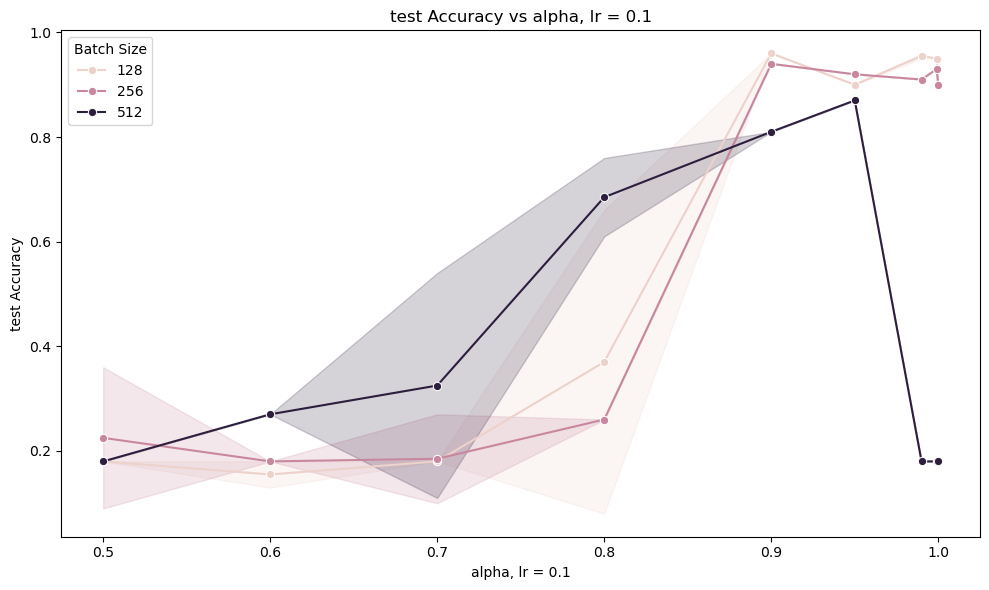

In [16]:
results_lr_01 = results[results["lr"] == 0.1]

trainOrTest = "test"

plt.figure(figsize=(10, 6))
sns.lineplot(
    data = results_lr_01,
    x = "alpha",
    y = f"{trainOrTest}_acc",
    hue = "batch_size",
    marker = "o"
)

plt.title(f"{trainOrTest} Accuracy vs alpha, lr = 0.1")
plt.xlabel("alpha, lr = 0.1")
plt.ylabel(f"{trainOrTest} Accuracy")
plt.legend(title="Batch Size")
plt.tight_layout()

plt.show()